In [1]:
import sys 
sys.path.append('/home/hydrogen/workspace/Space_GW/pespace')
sys.path.append('/home/hydrogen/workspace/Space_GW/wf4ti')

import taichi as ti
ti.init()
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline


[Taichi] version 1.6.0, llvm 15.0.4, commit f1c6fbbd, linux, python 3.10.12


[I 07/30/24 17:23:19.904 2006959] [shell.py:_shell_pop_print@23] Graphical python shell detected, using wrapped sys.stdout


[Taichi] Starting on arch=x64


In [3]:
from pespace.detectors import TDIChannelsData
from pespace.noise import noise_models

duration = 31536000
cadence = 10
mbhb = TDIChannelsData(label="injection_individual_MBHB")
mbhb.set_frequency_domain_data_with_zero_value(channels=("A", "E", "T", "X", "Y", "Z"), generation='1.5', duration=duration, cadence=cadence)
mbhb.set_frequency_domain_noise_power_density_from_analystic_model(noise_models['LISA_SciRDv1'])
noise_realization = mbhb.generate_realization_from_frequency_domain_noise_power_density()
mbhb.add_into_frequency_domian_data(noise_realization)


ValueError: You are setting TDIChannelData with channels of ('A', 'E', 'T', 'X', 'Y', 'Z'). While current supported channels are only including ('X', 'Y', 'Z', 'A', 'E', 'T')

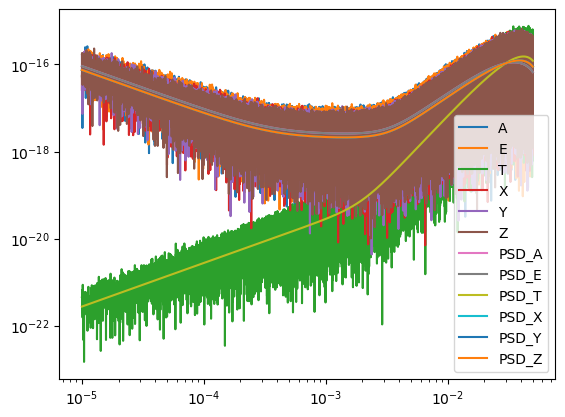

In [4]:
plt.figure()
plt.loglog(mbhb.frequency_samples_numpy_array, np.abs(mbhb.frequency_domain_TDI_data_numpy_array['A']), label="A")
plt.loglog(mbhb.frequency_samples_numpy_array, np.abs(mbhb.frequency_domain_TDI_data_numpy_array['E']), label="E")
plt.loglog(mbhb.frequency_samples_numpy_array, np.abs(mbhb.frequency_domain_TDI_data_numpy_array['T']), label="T")
plt.loglog(mbhb.frequency_samples_numpy_array, np.abs(mbhb.frequency_domain_TDI_data_numpy_array['X']), label="X")
plt.loglog(mbhb.frequency_samples_numpy_array, np.abs(mbhb.frequency_domain_TDI_data_numpy_array['Y']), label="Y")
plt.loglog(mbhb.frequency_samples_numpy_array, np.abs(mbhb.frequency_domain_TDI_data_numpy_array['Z']), label="Z")

plt.loglog(mbhb.frequency_samples_numpy_array, 0.5*(mbhb.frequency_domain_noise_power_density_numpy_array['A']*duration)**0.5, label="PSD_A")
plt.loglog(mbhb.frequency_samples_numpy_array, 0.5*(mbhb.frequency_domain_noise_power_density_numpy_array['E']*duration)**0.5, label="PSD_E")
plt.loglog(mbhb.frequency_samples_numpy_array, 0.5*(mbhb.frequency_domain_noise_power_density_numpy_array['T']*duration)**0.5, label="PSD_T")
plt.loglog(mbhb.frequency_samples_numpy_array, 0.5*(mbhb.frequency_domain_noise_power_density_numpy_array['X']*duration)**0.5, label="PSD_X")
plt.loglog(mbhb.frequency_samples_numpy_array, 0.5*(mbhb.frequency_domain_noise_power_density_numpy_array['Y']*duration)**0.5, label="PSD_Y")
plt.loglog(mbhb.frequency_samples_numpy_array, 0.5*(mbhb.frequency_domain_noise_power_density_numpy_array['Z']*duration)**0.5, label="PSD_Z")
plt.legend(loc='lower right' )